# Researcher1:
- 학생의 성적 데이터`train.csv` 데이터를 기반으로 데이터 전처리, 탐색적 데이터 분석(EDA)을 진행하고, `scikit-learn`을 사용하여 학생의 성적을 예측하는 회귀 모델링을 수행합니다.

### 데이터셋 소개

| 변수명 | 설명 |
| :--- | :--- |
| **Hours Studied** | 각 학생이 공부에 소요한 총 시간 |
| **Previous Scores** | 학생들이 이전 시험에서 얻은 점수 |
| **Extracurricular Activities** | 학생이 과외 활동에 참여하는지 여부 (예 또는 아니오) |
| **Sleep Hours** | 학생이 하루 평균 수면 시간 |
| **Sample Question Papers Practiced** | 학생이 연습한 모의고사 수 |
| **Performance Index** | **목표변수.** 각 학생의 전반적인 성취도를 나타내는 지표<br>(성취도 지수는 학생의 학업 성취도를 나타내며, 가장 가까운 정수로 반올림됩니다. 지수는 10에서 100까지이며, 값이 높을수록 더 나은 성취도를 나타냅니다.) |



In [10]:
# 한글 폰트 설치
# !apt-get install -y fonts-nanum

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


In [ ]:
# 필요한 라이브러리 임포트

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pickle #pkl
import os

# 나눔 폰트를 리스트에 추가
fe = fm.FontEntry(
    fname='/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf',
    name='NanumBarunGothic'
)
fm.fontManager.ttflist.insert(0, fe)

# 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

## 1. 데이터 로드

In [12]:
df = pd.read_csv("/content/drive/MyDrive/Codeit_Bootcamp/PART4/mission15/4팀_황유민/mission-result/researcher1/data/mission15_train.csv")

df.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,6,73,No,7,2,58.0
1,1,89,Yes,7,2,64.0
2,3,97,Yes,8,0,75.0
3,8,70,No,5,5,59.0
4,7,94,Yes,7,4,86.0


In [13]:
# 기본 데이터 정보 확인
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     7000 non-null   int64  
 1   Previous Scores                   7000 non-null   int64  
 2   Extracurricular Activities        7000 non-null   object 
 3   Sleep Hours                       7000 non-null   int64  
 4   Sample Question Papers Practiced  7000 non-null   int64  
 5   Performance Index                 7000 non-null   float64
dtypes: float64(1), int64(4), object(1)
memory usage: 328.3+ KB


(7000, 6)

### 데이터 기본 정보 요약
- 데이터 크기: 총 **7,000명**의 학생 데이터(행)와 **6개**의 변수(열)로 구성되어 있습니다.

- 결측치: 없습니다.

- 데이터 타입:

  - 수치형 변수 (5개):
    - Hours Studied,
    - Previous Scores,
    - Sleep Hours,
    - Sample Question Papers Practiced (정수형),
    - Performance Index (실수형)

  - 범주형 변수 (1개):
    - Extracurricular Activities(문자열(Yes/No))

- **Extracurricular Activities 변수를 모델 학습을 위해 0과 1로 변환하는 작업이 필요합니다.**

In [14]:
# 기술 통계량 확인

df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,7000.000000,7000.000000,7000.000000,7000.000000,7000.000000
mean,4.950000,69.429714,6.530571,4.607429,55.095143
std,2.590621,17.289197,1.696144,2.863550,19.151574
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,70.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


### 기술 통계량 요약

- Hours Studied (공부 시간): 평균 4.95시간 / 중앙값 5시간 (범위: 1~9)

- Previous Scores (이전 성적): 평균 69.4점 / 중앙값 69점 (범위: 40~99)

- Sleep Hours (수면 시간): 평균 6.5시간 / 중앙값 7시간 (범위: 4~9)

- Sample Papers (모의고사 횟수): 평균 4.6회 / 중앙값 5회 (범위: 0~9)

- Performance Index (최종 성적): 평균 55.1점 / 중앙값 55점 (범위: 10~100)

- **결론: 전 변수에 이상치가 없으며, 평균과 중앙값이 일치하는 안정적인 정규분포 형태입니다.**

## 2. 데이터 전처리

In [15]:
# 범주형 변수 고유값 확인
df["Extracurricular Activities"].unique()

array(['No', 'Yes'], dtype=object)

In [16]:
# 문자열(Yes/No) => 수치형(0, 1) 변환
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"No": 0,"Yes": 1})

# 확인
df["Extracurricular Activities"].value_counts(dropna=False)
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,6,73,0,7,2,58.0
1,1,89,1,7,2,64.0
2,3,97,1,8,0,75.0
3,8,70,0,5,5,59.0
4,7,94,1,7,4,86.0


## 3. 탐색적 데이터 분석(EDA)

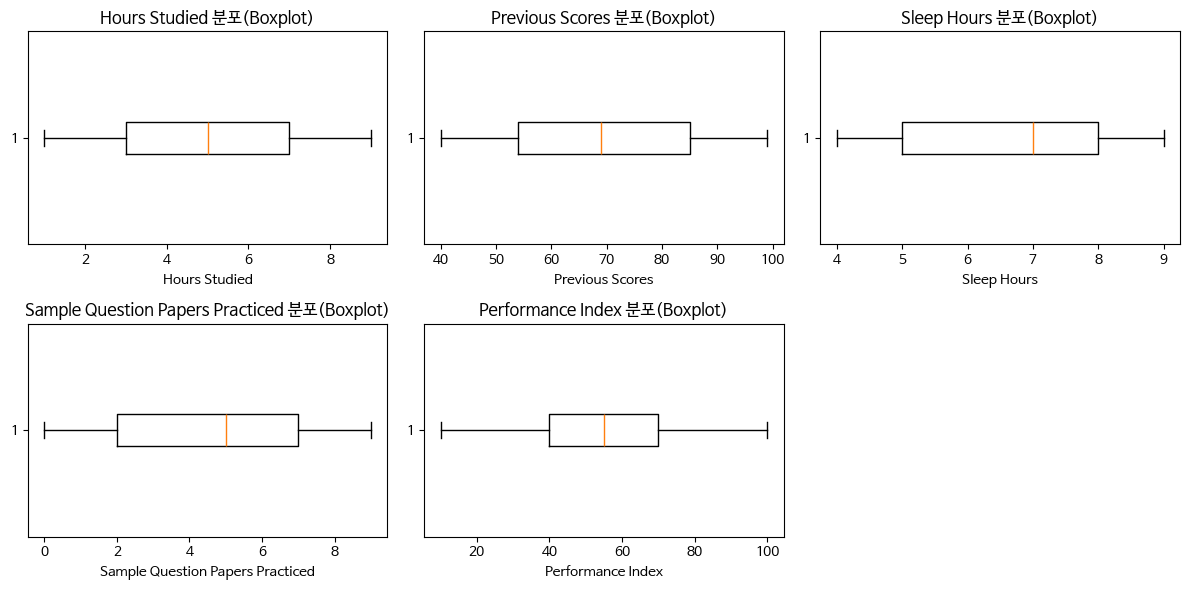

In [17]:
# 데이터 분포 확인

num_cols = ["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced", "Performance Index"]
plt.figure(figsize=(12, 6))

for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[col], vert=False)
    plt.title(f"{col} 분포(Boxplot)")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

- 앞선 기술 통계에서 확인했듯이 정규분포를 이루고 있습니다.
- **이상치**가 없습니다.

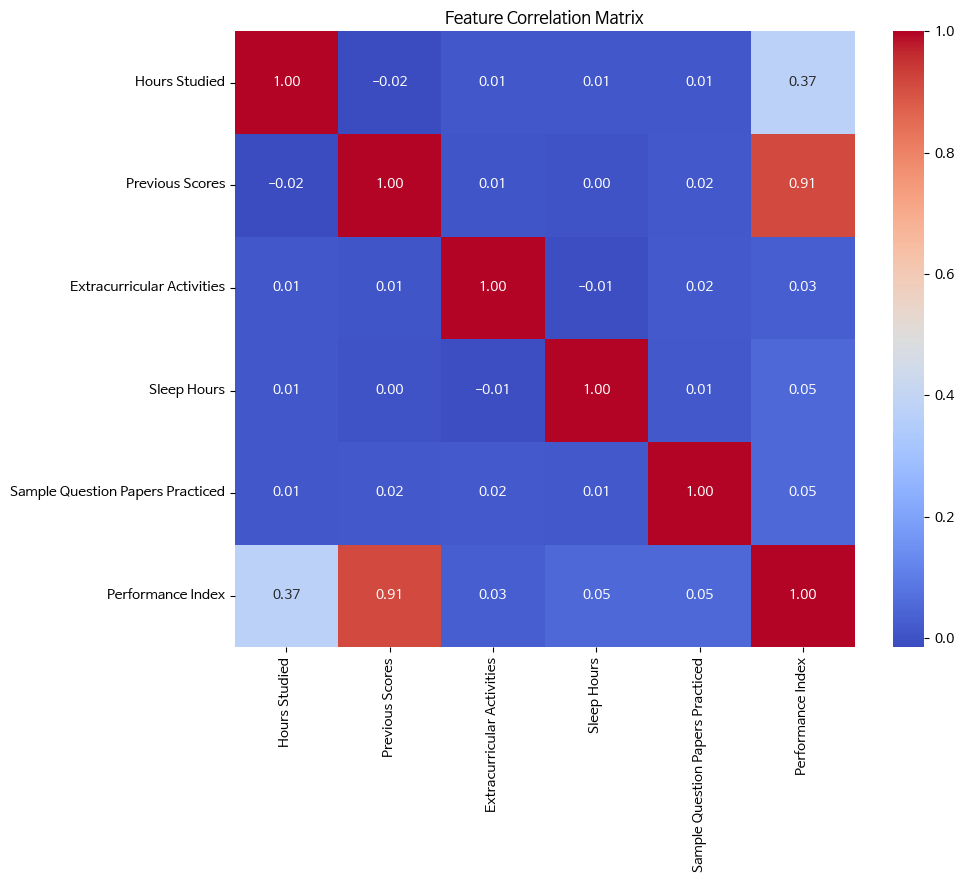

In [18]:
# 상관관계 분석

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

### 상관관계 분석 결과
| 구분 | 변수명 | 상관계수 | 분석 및 결론 |
| :--- | :--- | :---: | :--- |
| **핵심 동인** | **Previous Scores** | **0.91** | 현재 성적을 결정짓는 가장 강력한 핵심 요인 |
| | **Hours Studied** | **0.37** | 성적 상승과 두 번째로 비례하는 주요 요인 |
| **비핵심 요인** | **Sleep Hours 외 2종*** | **0.05 이하** | 성적에 미치는 영향력 거의 없음 (상관성 낮음)|


/tmp/ipykernel_2396/288388449.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df, x=col, y='Performance Index', alpha=0.3, palette='viridis')


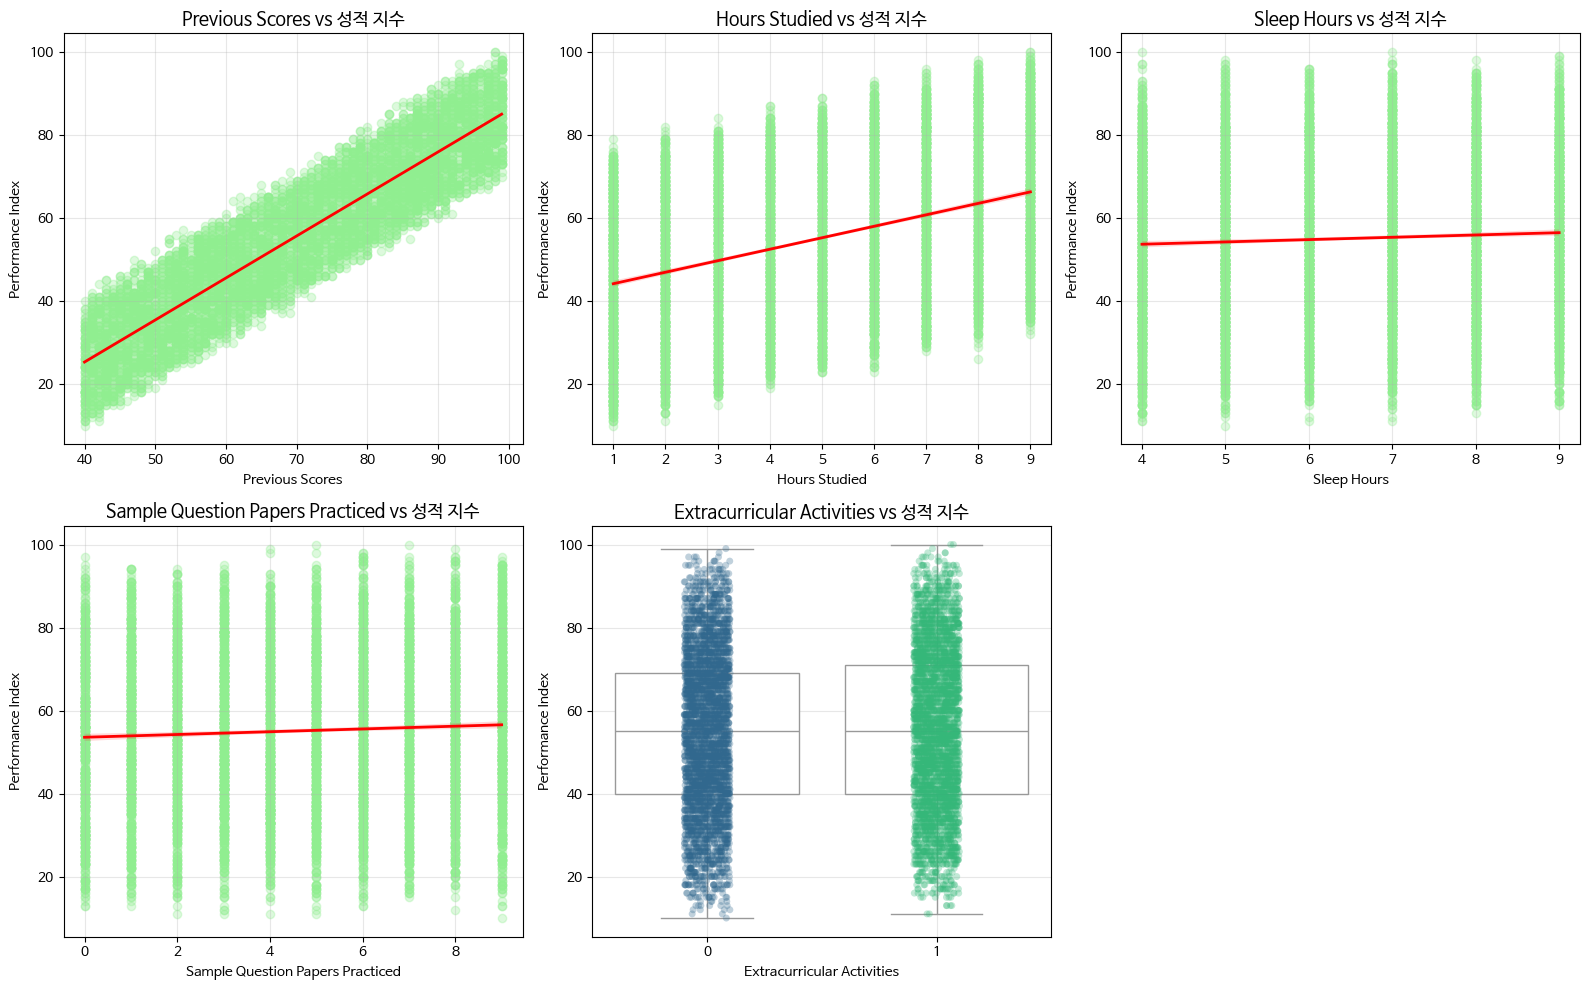

In [19]:
# 상관관계 패턴 시각화

# 1. 상관관계가 높은 순서대로 피처 리스트 배치
ordered_features = [
    "Previous Scores",                  # 1순위 (0.91)
    "Hours Studied",                    # 2순위 (0.37)
    "Sleep Hours",                      # 3순위 (0.05)
    "Sample Question Papers Practiced", # 4순위 (0.05)
    "Extracurricular Activities"        # 5순위 (0.03)
]

# 2. 그래프 기본 설정
plt.figure(figsize=(16, 10))

# 3. 순서대로 그래프 그리기
for i, col in enumerate(ordered_features, 1):
    plt.subplot(2, 3, i)

    if col == 'Extracurricular Activities':
        # 과외 활동은 0과 1로 나뉘므로 범주형에 맞는 stripplot + boxplot 혼합 사용
        sns.boxplot(data=df, x=col, y='Performance Index', color='white', showfliers=False)
        sns.stripplot(data=df, x=col, y='Performance Index', alpha=0.3, palette='viridis')
    else:
        # 수치형 변수들은 regplot을 사용해 '추세선(빨간선)'을 추가
        sns.regplot(data=df, x=col, y='Performance Index',
                    scatter_kws={'alpha': 0.3, 'color': 'lightgreen'},
                    line_kws={'color': 'red', 'linewidth': 2}) # 빨간색 추세선으로 상관관계 강조

    plt.title(f"{col} vs 성적 지수", fontsize=13)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 상관관계 패턴 분석
1. **Previous Scores (이전 성적)**:

  - 붉은색 추세선이 **가파르게 우상향**하고 있으며, 데이터가 **선 주변에 조밀히 모여 있습니다.**
2. **Hours Studied (공부 시간)**:

  - 추세선이 **우상향**을 그리고 있지만 Previous Scores(이전 성적)에 비해 점들이 **세로로 넓게 퍼져 있어** 예외가 존재합니다.

3. **비핵심 요인 3종** (Sleep Hours, Sample Papers, Extracurricular):

  - 수면 시간과 모의고사 연습 횟수는 추세선이 **수평**에 가깝습니다.

  - 과외 활동(Extracurricular Activities) 역시 두 그룹(0과 1)의 박스플롯 중앙값과 분포가 거의 동일하여 **유의미한 차이가 없습니다.**

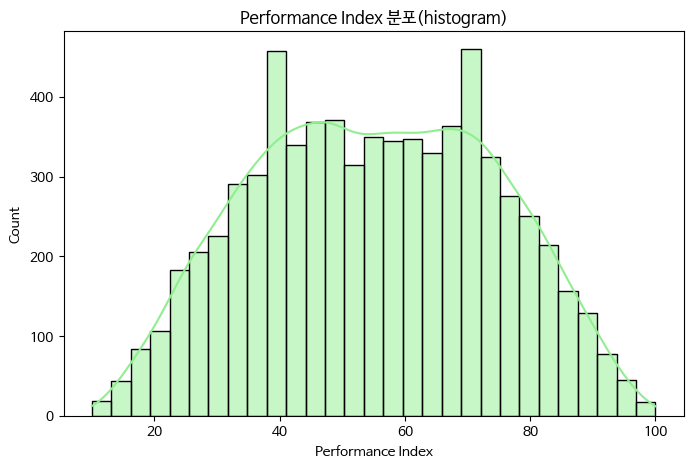

In [20]:
# 목표 변수(Performance Index) 분포 시각화
plt.figure(figsize=(8, 5))
sns.histplot(df['Performance Index'], kde=True, color='lightgreen')
plt.title('Performance Index 분포(histogram)')
plt.show()

### Performance Index 분포 분석 결과

- 목표 변수인 Performance Index는 평균 55~60점을 중심으로 한 정규 분포 형태를 보입니다.
- 하지만 40점대와 70점대 구간에서 데이터 빈도가 유독 높게 나타나는 특징이 있습니다.
- 극단적인 이상치(Outlier)가 발견되지 않으며, 데이터가 전 범위에 걸쳐 고르게 분포되어 있어 회귀 분석을 수행하기에 적합한 데이터로 판단됩니다.

## 4. 모델 학습 및 평가

In [21]:
# 데이터 전처리
# X(특성), y(타겟) 분리
X = df.drop('Performance Index', axis=1)
y = df['Performance Index']

# 학습/검증 데이터 분리
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습 데이터 크기: {X_train.shape}")
print(f"검증 데이터 크기: {X_val.shape}")

학습 데이터 크기: (5600, 5)
검증 데이터 크기: (1400, 5)


In [22]:
# 선형 회귀 모델
model = LinearRegression()
model.fit(X_train, y_train)

# 예측
y_pred = model.predict(X_val)

# 성능 평가
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Root Mean Squared Error (RMSE): 2.0103


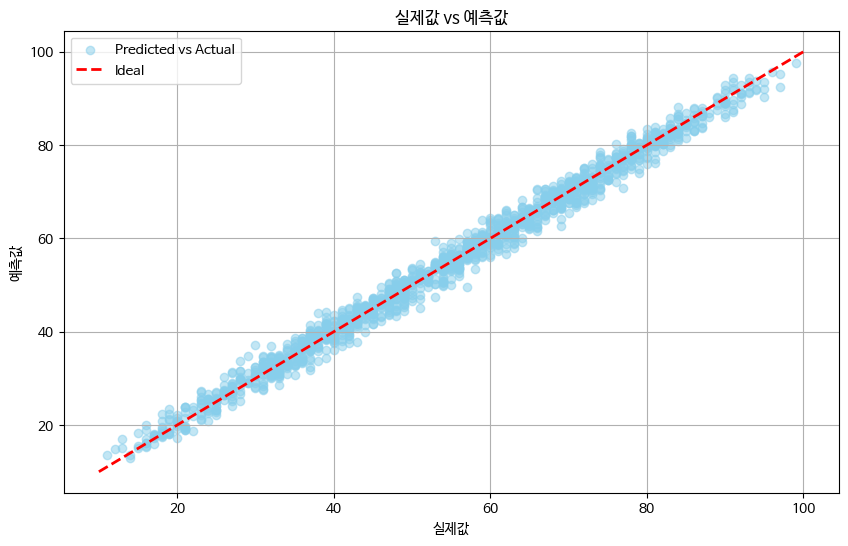

In [23]:
# 실제값 vs 예측값 시각화

plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.5, color='skyblue', label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ideal' ) # 대각선 (실제값=예측값)
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('실제값 vs 예측값')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
# 모델 저장
model_filename = 'model.pkl'
with open(model_filename, 'wb') as f:
    pickle.dump(model, f)

print(f"모델이 '{model_filename}'으로 저장되었습니다.")

모델이 'model.pkl'으로 저장되었습니다.
